In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
scores_vim_in = torch.load("outputs/2024-08-23/10-37-46/Textures-vim-in.pt").numpy()
scores_vim_val = torch.load("outputs/2024-08-23/10-37-46/val-vim-in.pt").numpy()
scores_vim_ood = torch.load("outputs/2024-08-23/10-37-46/Textures-vim-ood.pt").numpy()

-15.74443
-0.08427763


(array([4.540e+02, 3.224e+03, 1.381e+03, 4.010e+02, 1.120e+02, 3.700e+01,
        2.200e+01, 6.000e+00, 1.000e+00, 2.000e+00]),
 array([-0.08427763,  5.64447117, 11.37321949, 17.10196877, 22.83071709,
        28.55946541, 34.28821564, 40.01696396, 45.74571228, 51.4744606 ,
        57.20320892]),
 <BarContainer object of 10 artists>)

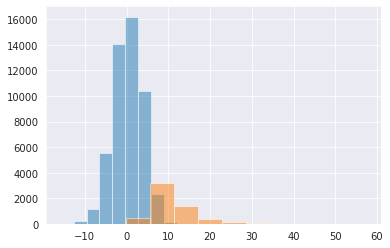

In [3]:
print(scores_vim_in.min())
print(scores_vim_ood.min())
plt.hist(scores_vim_in, alpha=0.5)
plt.hist(scores_vim_ood, alpha=0.5)

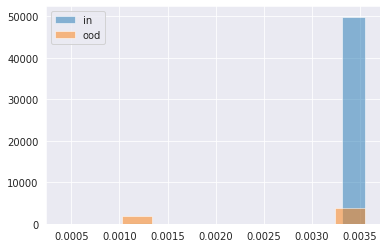

In [39]:
scores_naive_in = (
    torch.load("outputs/2024-08-23/10-37-46/Textures-mlnp-in.pt").squeeze().numpy()
)
scores_naive_ood = (
    torch.load("outputs/2024-08-23/10-37-46/Textures-mlnp-ood.pt").squeeze().numpy()
)

plt.hist(scores_naive_in, alpha=0.5, label="in")
plt.hist(scores_naive_ood, alpha=0.5, label="ood")
plt.legend()

In [40]:
from pytorch_ood.utils import OODMetrics
import numpy as np

m = OODMetrics()
m.update(torch.tensor(scores_vim_in), torch.ones(len(scores_vim_in)))
m.update(torch.tensor(scores_vim_ood), -torch.ones(len(scores_vim_ood)))
print(m.compute())

{'AUROC': 0.9837570190429688, 'AUPR-IN': 0.8991986513137817, 'AUPR-OUT': 0.9980911016464233, 'FPR95TPR': 0.08194000273942947}


In [41]:
from scipy.stats import genextreme

params = genextreme.fit(scores_vim_val)

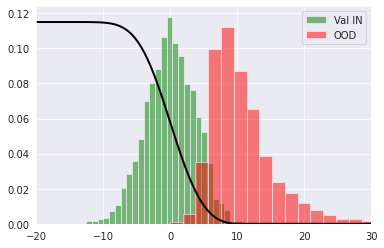

In [56]:
plt.hist(scores_vim_val, bins=30, density=True, alpha=0.5, color="g", label="Val IN")
plt.hist(scores_vim_ood, bins=30, density=True, alpha=0.5, color="r", label="OOD")
plt.xlim([-20, 30])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = genextreme.sf(x, *params)
plt.plot(x, p, "k", linewidth=2)

plt.legend()

plt.show()

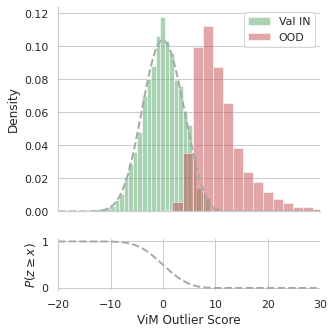

In [78]:
import seaborn as sb

# Set style and font size
sb.set(style="whitegrid")
plt.rcParams.update({"font.size": 20})  # Increase font size for paper printing

# Create a figure with two subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 5), gridspec_kw={"height_ratios": [4, 1]}
)

# First subplot: Histograms
ax1.hist(scores_vim_val, bins=30, density=True, alpha=0.5, color="g", label="Val IN")
ax1.hist(scores_vim_ood, bins=30, density=True, alpha=0.5, color="r", label="OOD")
ax1.set_xlim([-20, 30])
ax1.legend()
ax1.set_ylabel("Density")

x = np.linspace(xmin, xmax, 100)
p = genextreme.pdf(x, *params)
# ax1.plot(x, p, 'k', linewidth=2)
ax1.plot(x, p, color="darkgray", linestyle="--", linewidth=2)

# Second subplot: Survival function
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = genextreme.sf(x, *params)
ax2.plot(x, p, color="darkgray", linestyle="--", linewidth=2)
# ax2.plot(x, p, 'k', linewidth=2)
ax2.set_xlim([xmin, xmax])
ax2.set_xlabel("ViM Outlier Score")
ax2.set_ylabel("$P(z \geq x)$")

sb.despine(ax=ax1, right=True)
sb.despine(ax=ax2, right=True, bottom=True, left=False)

# Remove x-axis label from the first plot to avoid duplication
ax1.set_xlabel("")
ax1.set_xticks([])

# Show the plot
plt.tight_layout(pad=1)

plt.savefig("/home/ki/plot-celeb-a-vim.pdf", bbox_inches="tight")
plt.show()

In [11]:
p_ood = genextreme.sf(scores_vim_ood, *params)
p_in = genextreme.sf(scores_vim_in, *params)

(array([5.216e+03, 2.550e+02, 9.500e+01, 3.800e+01, 1.400e+01, 1.200e+01,
        6.000e+00, 1.000e+00, 0.000e+00, 3.000e+00]),
 array([0.        , 0.00018116, 0.00036232, 0.00054348, 0.00072463,
        0.00090579, 0.00108695, 0.00126811, 0.00144927, 0.00163043,
        0.00181159]),
 <BarContainer object of 10 artists>)

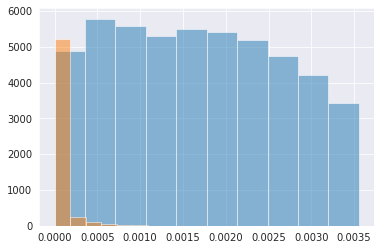

In [12]:
plt.hist(p_in * scores_naive_in, alpha=0.5)
plt.hist(p_ood * scores_naive_ood, alpha=0.5)

In [13]:
new_scores_in = p_in * scores_naive_in
new_scores_ood = p_ood * scores_naive_ood

m = OODMetrics()
m.update(-torch.tensor(new_scores_in), torch.ones(len(new_scores_in)))
m.update(-torch.tensor(new_scores_ood), -torch.ones(len(new_scores_ood)))
print(m.compute())

{'AUROC': 0.9868849515914917, 'AUPR-IN': 0.9170129895210266, 'AUPR-OUT': 0.9984517097473145, 'FPR95TPR': 0.06750000268220901}


In [14]:
m = OODMetrics()
m.update(-torch.tensor(p_in), torch.ones(len(p_in)))
m.update(-torch.tensor(p_ood), -torch.ones(len(p_ood)))
print(m.compute())

{'AUROC': 0.9836798310279846, 'AUPR-IN': 0.8975201845169067, 'AUPR-OUT': 0.9980838298797607, 'FPR95TPR': 0.08194000273942947}



# Mahalanobis

In [135]:
scores_detector_in = torch.load(
    "outputs/2024-08-27/15-47-29/LSUNCrop-mahalanobis-in.pt", map_location="cpu"
).numpy()
scores_detector_val_in = torch.load(
    "outputs/2024-08-27/15-47-29/val-mahalanobis-in.pt", map_location="cpu"
).numpy()
scores_detector_ood = torch.load(
    "outputs/2024-08-27/15-47-29/LSUNCrop-mahalanobis-ood.pt", map_location="cpu"
).numpy()

scores_naive_in = (
    torch.load("outputs/2024-08-27/15-47-29/LSUNCrop-mlnp-in.pt").squeeze().numpy()
)
scores_naive_ood = (
    torch.load("outputs/2024-08-27/15-47-29/LSUNCrop-mlnp-ood.pt").squeeze().numpy()
)
params = genextreme.fit(scores_detector_val_in)

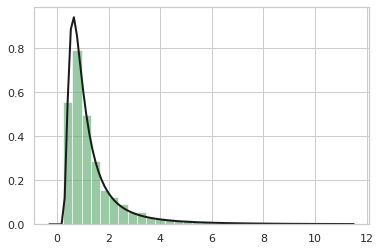

In [136]:
# params = genextreme.fit(scores_mahalanobis_val)
plt.hist(scores_detector_val_in, bins=30, density=True, alpha=0.6, color="g")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = genextreme.pdf(x, *params)
plt.plot(x, p, "k", linewidth=2)
plt.show()

Text(0.5, 1.0, 'Histogram of Mahalanobis Scores')

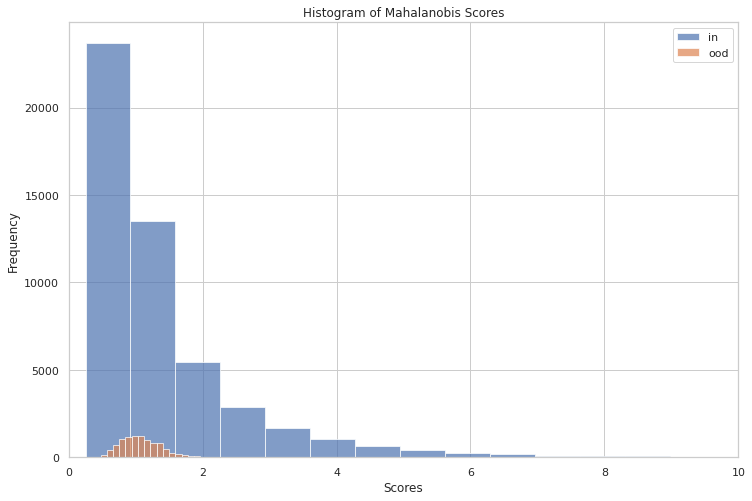

In [137]:
plt.figure(figsize=(12, 8))  # Make the plot larger

plt.hist(scores_detector_in, bins=30, label="in", alpha=0.7)
plt.hist(scores_detector_ood, bins=30, label="ood", alpha=0.7)

plt.xlim(0, 10)
plt.legend()
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.title("Histogram of Mahalanobis Scores")

In [138]:
m = OODMetrics()
m.update(-torch.tensor(scores_detector_in), torch.ones(len(scores_detector_in)))
m.update(-torch.tensor(scores_detector_ood), -torch.ones(len(scores_detector_ood)))
print(m.compute())

{'AUROC': 0.47023317217826843, 'AUPR-IN': 0.14150288701057434, 'AUPR-OUT': 0.8674993515014648, 'FPR95TPR': 0.7527400255203247}


In [4]:
import seaborn as sb
import torch
from scipy.stats import genextreme
from matplotlib import pyplot as plt
import numpy as np


sb.set_style("whitegrid")
gridline_style = {"color": "gray", "linestyle": "--", "linewidth": 0.5, "alpha": 0.3}

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)
plt.rcParams.update(
    {
        "font.size": 24,  # General font size
        "axes.titlesize": 20,  # Title font size
        "axes.labelsize": 18,  # Axis label font size
        "xtick.labelsize": 16,  # X tick label font size
        "ytick.labelsize": 16,  # Y tick label font size
        "legend.fontsize": 14,  # Legend font size
    }
)


def draw(dataset_name, detector_name, detector_pretty, limit=None):
    scores_detector_in = torch.load(
        f"outputs/2025-01-24/17-39-35/scores-{dataset_name}-{detector_name}.pt",
        map_location="cpu",
    )["ID"].numpy()

    print(scores_detector_in)
    # scores_detector_val_in = torch.load(
    #     f"outputs/2025-01-24/17-39-35/scores-val-{detector_name}.pt", map_location="cpu"
    # )["ID"].numpy()
    scores_detector_ood = torch.load(
        f"outputs/2025-01-24/17-39-35/scores-{dataset_name}-{detector_name}.pt",
        map_location="cpu",
    )["OOD"].numpy()

    print(scores_detector_ood)

    # scores_naive_in = torch.load("outputs/2024-08-27/15-47-29/LSUNCrop-mlnp-in.pt").squeeze().numpy()
    # scores_naive_ood = torch.load("outputs/2024-08-27/15-47-29/LSUNCrop-mlnp-ood.pt").squeeze().numpy()
    params = genextreme.fit(scores_detector_in)

    p_ood = genextreme.sf(scores_detector_ood, *params)
    p_in = genextreme.sf(scores_detector_in, *params)

    # Create a figure with two subplots (2 rows, 1 column)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(5, 4), gridspec_kw={"height_ratios": [4, 1]}
    )

    # First subplot: Histograms
    ax1.hist(
        scores_detector_in, bins=30, density=True, alpha=0.5, label="ID"
    )  # color='g',
    ax1.hist(
        scores_detector_ood, bins=30, density=True, alpha=0.5, label="OOD"
    )  # color='r',
    if limit:
        ax1.set_xlim(limit)
    ax1.legend()
    ax1.set_ylabel("Density")
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = genextreme.pdf(x, *params)
    # ax1.plot(x, p, 'k', linewidth=2)
    ax1.plot(x, p, color="darkgray", linestyle="--", linewidth=2)

    # Second subplot: Survival function

    x = np.linspace(xmin, xmax, 100)
    p = genextreme.sf(x, *params)
    ax2.plot(x, p, color="darkgray", linestyle="--", linewidth=2, fillstyle="bottom")
    ax2.fill_between(x, p, color="darkgray", alpha=0.3)
    # ax2.plot(x, p, 'k', linewidth=2)
    ax2.set_xlim([xmin, xmax])
    ax2.set_xlabel(f"{detector_pretty} Outlier Score")
    ax2.set_ylabel("$P(x \geq X)$")

    sb.despine(ax=ax1, right=True)
    sb.despine(ax=ax2, right=True, bottom=True, left=False)

    # Remove x-axis label from the first plot to avoid duplication
    ax1.set_xlabel("")
    ax1.set_xticks([])

    ax1.grid(**gridline_style)  # Apply the subtle gridline style
    ax2.grid(**gridline_style)  # Apply the subtle gridline style

    # Show the plot
    plt.tight_layout(pad=0.5)

    plt.savefig(f"/home/ki/plot-celeb-a-{detector_pretty}.pdf", bbox_inches="tight")
    plt.close()

    # plt.show()

In [8]:
detectors = {
    "dice": {"detector_pretty": "DICE", "limit": [-0.8, 0.0]},
    "ebo": {"detector_pretty": "EBO", "limit": [-0.8, 0.0]},
    "mahalanobis": {"detector_pretty": "Mahalanobis", "limit": [0, 0.5]},
    # "msp": "MSP",
    "vim": {"detector_pretty": "ViM", "limit": [-0.3, 0.4]},
    "react": {"detector_pretty": "ReAct", "limit": [-1.0, 0.0]},
    "she": {"detector_pretty": "SHE", "limit": [-0.8, 0.0]},
    "msp": {"detector_pretty": "MSP", "limit": [-2, -1.75]},
}
dataset_name = "inaturalist"

for detector_name, params in detectors.items():
    draw(dataset_name, detector_name, **params)

[-0.05202693 -0.40140086 -0.09628015 ... -0.11580367 -0.03236208
 -0.12451494]
[-0.16074932 -0.05567706 -0.4297545  ... -0.1894544  -0.05353273
 -0.19806002]
[-0.04895 -0.4014  -0.08936 ... -0.1026  -0.01539 -0.1202 ]
[-0.1608  -0.05563 -0.4297  ... -0.1865  -0.04126 -0.1979 ]
[0.02871458 0.17535314 0.06907863 ... 0.05086029 0.02022125 0.03277038]
[0.24051715 0.16638196 0.23943442 ... 0.17214106 0.17916237 0.18408026]
[ 0.04978764 -0.08235733  0.08939005 ...  0.04731045  0.06725377
 -0.00313705]
[ 0.17660668  0.20020153 -0.05350653 ...  0.13819827  0.25460735
  0.09809656]
[-0.19705708 -0.961507   -0.35308343 ... -0.3566418  -0.07340062
 -0.3305084 ]
[-0.5694339  -0.3007467  -0.7633251  ... -0.5565997  -0.25109628
 -0.66184497]
[-0.06609777 -0.37368444 -0.17685696 ... -0.12319759 -0.02288164
 -0.04423601]
[-0.24479909 -0.14174253 -0.47511727 ... -0.28691134 -0.18852918
 -0.24262384]
[-1.991 -2.    -2.    ... -2.    -1.567 -2.   ]
[-2.    -1.997 -2.    ... -2.    -1.992 -2.   ]


/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/numpy/core/_methods.py:215: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/scipy/stats/_distn_infrastructure.py:2752: RuntimeWarning: invalid value encountered in scalar divide
  Shat = sqrt(mu2hat / mu2)


In [1]:
def catnumber(n):
    ans = 1.0
    for k in range(2, n + 1):
        ans = ans * (n + k) / k
    return ans

In [ ]:
# Number of constraints

In [34]:
from mining import generate_all_constraints

_ = generate_all_constraints(4)

max_depth = 1
n_operators = 4
n_propositions = 6

sum(
    [
        catnumber(depth - 1)
        * (2 * n_propositions) ** (depth)
        * (n_operators) ** (depth - 1)
        for depth in range(1, max_depth + 1)
    ]
)

sum(
    [
        (2 * n_propositions) ** (depth) * (n_operators) ** (depth - 1)
        for depth in range(1, max_depth + 1)
    ]
)

for depth in [1, 2, 3]:
    print(
        (2 * n_propositions) ** (depth) * (n_operators) ** (depth - 1),
        catnumber(depth - 1),
    )

Total unique expressions: 6691404

6691404


KeyboardInterrupt: 

In [13]:
import torch

scores_detector_in1 = torch.load(
    "outputs/2024-08-27/15-47-29/Textures-vim-in.pt", map_location="cpu"
).numpy()
scores_detector_ood1 = torch.load(
    "outputs/2024-08-27/15-47-29/Textures-vim-ood.pt", map_location="cpu"
).numpy()

scores_detector_in2 = torch.load(
    "outputs/2024-08-27/15-47-29/Textures-mlnp-in.pt", map_location="cpu"
).numpy()
scores_detector_ood2 = torch.load(
    "outputs/2024-08-27/15-47-29/Textures-mlnp-ood.pt", map_location="cpu"
).numpy()

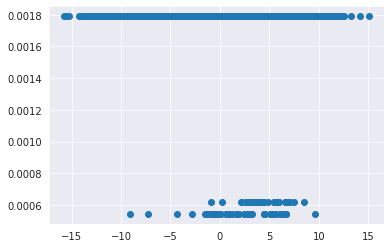

In [14]:
import matplotlib.pyplot as plt

plt.scatter(scores_detector_in1, scores_detector_in2)

In [15]:
from scipy.stats import spearmanr

spearmanr(scores_detector_in1, scores_detector_in2)

SignificanceResult(statistic=-0.032250320085489705, pvalue=5.469758771118116e-13)

In [16]:
spearmanr(scores_detector_ood1, scores_detector_ood2)

SignificanceResult(statistic=0.04128369217311153, pvalue=0.001928439953258177)

In [12]:
from omegaconf import OmegaConf
from os.path import join
import pandas as pd

results = []

root = f"multirun/sweep-target-att"


def proc(path):
    cfg = OmegaConf.load(join(path, ".hydra", "config.yaml"))
    df = pd.read_pickle(join(path, "results-agg.pkl"))
    # print(df)
    r = {
        "target": cfg.target_att,
        "perf1": df.loc["ViM"]["AUROC"]["mean"]["mean"],
        "perf2": df.loc["MLN+ViM"]["AUROC"]["mean"]["mean"],
    }
    return r


for i in range(14):
    path = join(root, str(i))
    results.append(proc(path))

In [13]:
results

[{'target': 'blond_hair',
  'perf1': 98.60287621617317,
  'perf2': 97.97663822770119},
 {'target': 'gray_hair',
  'perf1': 99.6220064163208,
  'perf2': 99.63562861084938},
 {'target': 'receding_hairline',
  'perf1': 98.89066129922867,
  'perf2': 99.14665155112743},
 {'target': 'heavy_makeup',
  'perf1': 95.9380379319191,
  'perf2': 96.01960986852646},
 {'target': 'brown_hair',
  'perf1': 84.93542894721031,
  'perf2': 91.4413669705391},
 {'target': 'young', 'perf1': 98.96413862705231, 'perf2': 99.09136652946472},
 {'target': 'wearing_lipstick',
  'perf1': 97.58595414459705,
  'perf2': 96.30035318434238},
 {'target': 'mustache',
  'perf1': 99.69179876148701,
  'perf2': 99.73130263388157},
 {'target': 'male', 'perf1': 99.6100215613842, 'perf2': 99.04030919075012},
 {'target': 'goatee', 'perf1': 99.80418257415295, 'perf2': 99.82352994382381},
 {'target': 'attractive',
  'perf1': 89.23114985227585,
  'perf2': 93.14323723316193},
 {'target': 'smiling', 'perf1': 97.60774739086628, 'perf2': 98